# Relatividad y Gravitación
## Prof. Jorge I. Zuluaga

### Cuaderno de Clase: Geodésicas nulas en la Métrica de Schwarzschild

## Paquetes requeridos

In [114]:
!pip install -Uq einsteinpy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [115]:
import einsteinpy.symbolic as es
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
from scipy.integrate import solve_ivp
import spiceypy as spy

## Geodésica nula

In [116]:
def edg_schwarzschild(tau, Ys, G, M, c):
    t, r, theta, phi, Ut, Ur, Utheta, Uphi = Ys

    rs = 2 * G * M / c**2  # radio de Schwarzschild

    # Derivadas de las coordenadas
    dT_dtau = Ut
    dr_dtau = Ur
    dtheta_dtau = Utheta
    dphi_dtau = Uphi

    # Ecuaciones geodésicas: d²x^σ/dτ² = -Γ^σ_{μν} ẋ^μ ẋ^ν
    # Γ^0_{01} = Γ^0_{10} = G*M / (r*(-2*G*M + c²*r))
    dUt_dtau = -2 * G * M / (r * (-2 * G * M + c**2 * r)) * Ut * Ur

    # Γ^1_{00}, Γ^1_{11}, Γ^1_{22}, Γ^1_{33}
    dUr_dtau = (- (- G * M * (2 * G * M - c**2 * r) / (c**4 * r**3)) * Ut**2
                - G * M * (2 * G * M - c**2 * r) / (c**4 * r**3 * (1 - rs/r)**2) * Ur**2
                - (2 * G * M - c**2 * r) / c**2 * Utheta**2
                - (2 * G * M - c**2 * r) / c**2 * np.sin(theta)**2 * Uphi**2)

    # Γ^2_{12} = Γ^2_{21} = 1/r,  Γ^2_{33} = -sin(θ)cos(θ)
    dUtheta_dtau = (-2 / r * Ur * Utheta
                   + np.sin(theta) * np.cos(theta) * Uphi**2)

    # Γ^3_{13} = Γ^3_{31} = 1/r,  Γ^3_{23} = Γ^3_{32} = cos(θ)/sin(θ)
    dUphi_dtau = (-2 / r * Ur * Uphi
                 - 2 * np.cos(theta) / np.sin(theta) * Utheta * Uphi)

    return [dT_dtau, dr_dtau, dtheta_dtau, dphi_dtau,
            dUt_dtau, dUr_dtau, dUtheta_dtau, dUphi_dtau]

In [117]:
edg_schwarzschild(1, [1, 1, 1, 1, 1, 1, 1, 1], 2, 2, 2)

[1,
 1,
 1,
 1,
 2.0,
 np.float64(-1.708073418273571),
 np.float64(-1.545351286587159),
 np.float64(-3.2841852318686615)]

### Solución a las ecuaciones geodésica

Como aparece en el panorama la constante de gravitación universal $G$ ahora las unidades se escogen no solo para que sean relativistas $c=1$ sino también para que sean unidades canónicas $G=1$. Las ecuaciones de las unidades son:

$$
c = \frac{U_L}{U_T}\\
G = \frac{U_L^3}{U_M U_T^2}\\
$$

Despejando $U_T$ de la primera ecuación y reemplazandola en la segunda queda:

$$
G = \frac{c^2 U_L}{U_M}\\
$$

Si fijamos la unidad de masa, la unidad de longitud queda:

$$
U_L = \frac{G U_M}{c^2}\\
$$

Vamos a simular el movimiento de un cuerpo alrededor de un agujero negro con la masa del Sol entonces escogemos como unidad de masa la masa solar:

In [118]:
# Unidades relativistas: c = 1, c = UL / UT
UM = pc.constantes.M_sun # en kg
UL = pc.constantes.G * UM / pc.constantes.c**2 # en metros
UT = UL / pc.constantes.c

# Unidades derivadas
UV = UL / UT
UA = UL / UT**2

# Constantes
G = 1
C = 1

UL, UT, UV, UA, C

(np.float64(1476.6250380501249),
 np.float64(4.9254909476412675e-06),
 np.float64(299792458.0),
 np.float64(60865497711160.234),
 1)

Vemos que la unidad de longitud es 1476 m = 1.5 km, lo que nos da una idea de a qué distancia poner el cuerpo para su trayectoria.

Condiciones iniciales:

Vamos a colocar un rayo de luz 5000 km del centro y moviéndose con una velocidad igual a la de la luz $v_\phi=c$:

### Condiciones iniciales

In [119]:
M = 1
s = G * M / C**2

t0 = 0
r0 = 5 * s
teta0 = np.pi / 2 
fi0 = 0 

vr0 = 0
vteta0 = 0 
vfi0 = C / r0

r0, teta0, fi0, vr0, vteta0, vfi0

(5.0, 1.5707963267948966, 0, 0, 0, 0.2)

Condiciones iniciales en el espacio-tiempo:

In [120]:
T0 = C*t0
# Las posiciones son las mismas
g00 = 1 - 2*G*M/ (C**2 * r0)
g11 = - 1 / (1 - 2*G*M/(C**2*r0))
g22 = - r0**2
g33 = - r0**2 * np.sin(teta0)**2

# En el caso de partícula: c^2 = g_00 Ut^2 + g_11 Ur^2 + g_22 Uteta^2 + g_33 Uphi^2
# En el caso de fotón: 0 = g_00 Ut^2 + g_11 Ur^2 + g_22 Uteta^2 + g_33 Uphi^2
Ut0 = np.sqrt((-g11*vr0**2 -g22*vteta0**2 - g33*vfi0**2)/g00)

Ur0 = vr0 
Uteta0 = vteta0
Uphi0 = vfi0

T0, r0, teta0, fi0, Ut0, Ur0, Uteta0, Uphi0

(0, 5.0, 1.5707963267948966, 0, np.float64(1.2909944487358058), 0, 0, 0.2)

Tiempos y condiciones iniciales:

In [135]:
T = s / C # El tiempo caracteristico de movimiento alrededor del agujero

taus = np.linspace(0, 100*T, 1000)
Ys0 = [T0, r0, teta0, fi0, Ut0, Ur0, Uteta0, Uphi0]

def fin_trayectoria(tau, Ys, G, M, C):
    t, r, theta, phi, Ut, Ur, Utheta, Uphi = Ys
    # Funcion que sea cero cuando ocurre el evento:
    f = r - 2*s
    return f

fin_trayectoria.terminal = True
fin_trayectoria.direction = -1

def limite_exterior(tau, Ys, G, M, C):
    t, r, theta, phi, Ut, Ur, Utheta, Uphi = Ys
    # Funcion que sea cero cuando ocurre el evento:
    f = r - 10*s
    return f

limite_exterior.terminal = True
limite_exterior.direction = +1

solucion = solve_ivp(edg_schwarzschild, 
                     (taus[0], taus[-1]), 
                     Ys0, 
                     t_eval=taus,
                     args=(G, M, C), 
                     events=[fin_trayectoria, limite_exterior],
                     method='Radau')

solucion

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.001e-01 ...  9.990e+01  1.000e+02]
        y: [[ 0.000e+00  1.292e-01 ...  1.184e+02  1.185e+02]
            [ 2.000e+01  2.000e+01 ...  3.947e+02  3.951e+02]
            ...
            [ 0.000e+00  2.451e-19 ...  4.937e-20  4.927e-20]
            [ 2.000e-01  1.999e-01 ...  5.134e-04  5.124e-04]]
      sol: None
 t_events: [array([], dtype=float64), array([], dtype=float64)]
 y_events: [array([], dtype=float64), array([], dtype=float64)]
     nfev: 147
     njev: 5
      nlu: 32

Extraemos la solución y la ponemos en unidades del sistema internacional:

In [136]:
ts = solucion.y[0] / C * UT
rs = solucion.y[1] 
tetas = solucion.y[2] 
fis = solucion.y[3] 

# Convertir a coordenadas cartesianas para graficar
xs = rs * np.sin(tetas) * np.cos(fis)
ys = rs * np.sin(tetas) * np.sin(fis)
zs = rs * np.cos(tetas)

Graficamos:

(np.float64(-4.061338989958774),
 np.float64(21.145778047140894),
 np.float64(-21.852861298701203),
 np.float64(414.91008727272526))

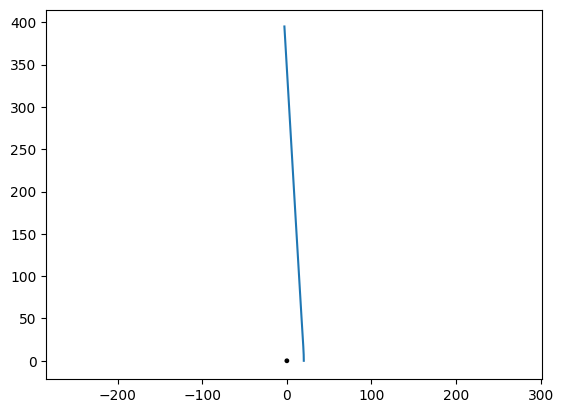

In [137]:
fig, ax = plt.subplots()
plt.plot(xs / s, ys / s)
circle = plt.Circle((0, 0), 2*s, color='black') # Singularidad métrica
ax.add_patch(circle)
plt.axis('equal')

## Empacarlo en rutina

In [138]:
!pip install -Uq ipywidgets
from ipywidgets import interact


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [139]:
@interact(r0=(3, 10, 0.5))
def geodesica_nula(r0=5):
    
    M = 1
    s = G * M / C**2

    t0 = 0
    #r0 = 5e3 / UL # 5000 km
    teta0 = np.pi / 2 
    fi0 = 0 

    vr0 = 0.0
    vteta0 = 0 
    vfi0 = C / r0 # 

    r0, teta0, fi0, vr0, vteta0, vfi0

    T0 = C*t0
    # Las posiciones son las mismas
    g00 = 1 - 2*G*M/ (C**2 * r0)
    g11 = - 1 / (1 - 2*G*M/(C**2*r0))
    g22 = - r0**2
    g33 = - r0**2 * np.sin(teta0)**2

    # En el caso de partícula: c^2 = g_00 Ut^2 + g_11 Ur^2 + g_22 Uteta^2 + g_33 Uphi^2
    # En el caso de fotón: 0 = g_00 Ut^2 + g_11 Ur^2 + g_22 Uteta^2 + g_33 Uphi^2
    Ut0 = np.sqrt((-g11*vr0**2 -g22*vteta0**2 - g33*vfi0**2)/g00)

    Ur0 = vr0 
    Uteta0 = vteta0
    Uphi0 = vfi0

    T0, r0, teta0, fi0, Ut0, Ur0, Uteta0, Uphi0

    s = G*M / C**2
    T = s / C # El tiempo caracteristico de movimiento alrededor del agujero

    taus = np.linspace(0, 60*T, 1000)
    Ys0 = [T0, r0, teta0, fi0, Ut0, Ur0, Uteta0, Uphi0]
    solucion = solve_ivp(edg_schwarzschild, 
                        (taus[0], taus[-1]), 
                        Ys0, 
                        t_eval=taus,
                        args=(G, M, C), 
                        method='Radau')

    ts = solucion.y[0] / C * UT
    rs = solucion.y[1] 
    tetas = solucion.y[2] 
    fis = solucion.y[3] 

    # Convertir a coordenadas cartesianas para graficar
    xs = rs * np.sin(tetas) * np.cos(fis)
    ys = rs * np.sin(tetas) * np.sin(fis)
    zs = rs * np.cos(tetas)

    fig, ax = plt.subplots()
    ax.plot(xs / s, ys / s)
    circle = plt.Circle((0, 0), 2*s, color='black') # Singularidad métrica
    ax.add_patch(circle)
    ax.axis('equal')
    plt.show()

interactive(children=(FloatSlider(value=5.0, description='r0', max=10.0, min=3.0, step=0.5), Output()), _dom_c…

## Tiremos varios rayos

In [140]:
def geodesica_nula_trayectoria(r0=5):
    
    M = 1

    t0 = 0
    #r0 = 5e3 / UL # 5000 km
    teta0 = np.pi / 2 
    fi0 = 0 

    vr0 = 0.0
    vteta0 = 0 
    vfi0 = C / r0 # 

    r0, teta0, fi0, vr0, vteta0, vfi0

    T0 = C*t0
    # Las posiciones son las mismas
    g00 = 1 - 2*G*M/ (C**2 * r0)
    g11 = - 1 / (1 - 2*G*M/(C**2*r0))
    g22 = - r0**2
    g33 = - r0**2 * np.sin(teta0)**2

    # En el caso de partícula: c^2 = g_00 Ut^2 + g_11 Ur^2 + g_22 Uteta^2 + g_33 Uphi^2
    # En el caso de fotón: 0 = g_00 Ut^2 + g_11 Ur^2 + g_22 Uteta^2 + g_33 Uphi^2
    Ut0 = np.sqrt((-g11*vr0**2 -g22*vteta0**2 - g33*vfi0**2)/g00)

    Ur0 = vr0 
    Uteta0 = vteta0
    Uphi0 = vfi0

    T0, r0, teta0, fi0, Ut0, Ur0, Uteta0, Uphi0

    s = G*M / C**2
    T = s / C # El tiempo caracteristico de movimiento alrededor del agujero

    taus = np.linspace(0, 60*T, 1000)
    Ys0 = [T0, r0, teta0, fi0, Ut0, Ur0, Uteta0, Uphi0]
    solucion = solve_ivp(edg_schwarzschild, 
                        (taus[0], taus[-1]), 
                        Ys0, 
                        t_eval=taus,
                        args=(G, M, C), 
                        events=[fin_trayectoria, limite_exterior],
                        method='Radau')

    ts = solucion.y[0] / C * UT
    rs = solucion.y[1] 
    tetas = solucion.y[2] 
    fis = solucion.y[3] 

    # Convertir a coordenadas cartesianas para graficar
    xs = rs * np.sin(tetas) * np.cos(fis)
    ys = rs * np.sin(tetas) * np.sin(fis)
    zs = rs * np.cos(tetas)

    return xs, ys, zs

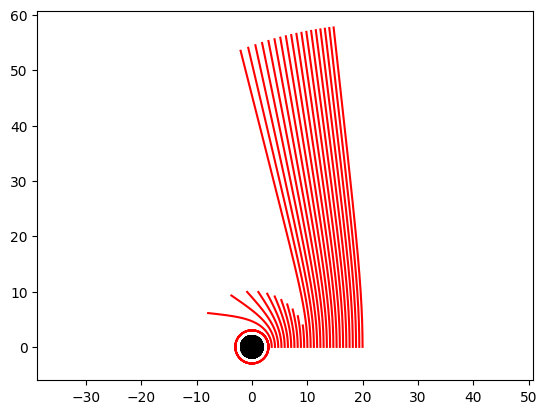

In [141]:
fig, ax = plt.subplots()
for r0 in np.linspace(3*s, 20*s, 30):
    xs, ys, zs = geodesica_nula_trayectoria(r0)
    ax.plot(xs / s, ys / s, 'r')
    circle = plt.Circle((0, 0), 2*s, color='black') # Singularidad métrica
    ax.add_patch(circle)
    ax.axis('equal')
    ax.grid()